# 1. Definirea Problemei

### Contextul problemei
Ești în fața unui anunț pe OLX. Mașina arată bine, prețul pare ok, vânzătorul
zâmbește în poză și îți jură că „a fost ținută în garaj și condusă doar duminica
la biserică". Dar tu nu știi dacă prețul e corect, prea mare sau o afacere a
vieții tale.

Felicitări — tocmai ai intrat în junglă numită **piața mașinilor second hand**.

Dincolo de glumă, evaluarea corectă a prețului unei mașini rulate este o problemă
reală cu mize financiare serioase: cumpărătorul vrea să nu plătească în plus,
vânzătorul vrea să nu lase bani pe masă, iar dealerii trăiesc din diferența
dintre cei doi.

Întrebarea este: **poate un model de machine learning să stabilească prețul corect
al unei mașini second hand, mai bine decât instinctul unui vânzător?**

---

### 1.1 Ce se urmărește?
Folosind date despre 1.000 de vehicule second hand, vom construi un model de
regresie capabil să prezică **prețul curent de revânzare** al unei mașini pe baza
caracteristicilor sale tehnice și a stării generale.

---

### 1.2 Ce se prezice?
Variabila țintă este `current price` — prețul de revânzare al mașinii, exprimat
în unități monetare (rupii indiande, INR).

| Proprietate | Valoare |
|-------------|---------|
| **Tip**     | Variabilă continuă (regresie) |
| **Minim**   | ~28.226 INR |
| **Maxim**   | ~584.267 INR |
| **Medie**   | ~308.520 INR |
| **Std**     | ~126.073 INR |

Distribuția prețului este aproximativ normală, fără asimetrii extreme —
condiții favorabile pentru modele de regresie.

---

### 1.3 Variabile de intrare (10 caracteristici)

| Categorie | Features | Semnificație |
|-----------|----------|--------------|
| **Prețuri de referință** | `on road old`, `on road now` | Prețul original și cel curent pe șosea |
| **Uzură** | `years`, `km` | Vechimea și kilometrajul — cu cât mai mari, cu atât mai mic prețul |
| **Calitate** | `rating`, `condition` | Evaluarea generală și starea obiectivă a mașinii |
| **Performanță** | `top speed`, `hp`, `torque` | Viteza maximă, caii putere și cuplul motor |
| **Consum** | `economy` | Eficiența combustibilului |

---

### 1.4 Relevanța practică
Un model predictiv de preț poate fi util pentru:
- **Cumpărători** — verifică rapid dacă prețul cerut e corect sau umflat
- **Vânzători** — stabilesc un preț competitiv bazat pe date, nu pe intuiție
- **Dealeri** — automatizează evaluarea stocului și identifică oportunități
- **Platforme de anunțuri** — oferă estimări automate utilizatorilor (ca la
  OLX, AutoScout24 sau CarGurus)

---

### 1.5 De ce am ales această problemă?
Pentru că e concretă, e universală și are o aplicabilitate imediată în lumea reală.
Aproape oricine a cumpărat sau va cumpăra o mașină la mâna a doua și s-a întrebat
dacă plătește prețul corect.

Pe lângă asta, datele combină factori tehnici obiectivi (`hp`, `torque`, `km`)
cu evaluări subiective (`rating`, `condition`), oferind un context ideal pentru
a testa și compara mai mulți algoritmi de regresie și a observa cum fiecare
interpretează diferit relația dintre caracteristici și preț.

Iar dacă modelul funcționează — data viitoare când cineva ne spune că mașina
„a fost condusă doar duminica", avem cu ce să îl contrazic cu date.

---
# 2. Analiza Exploratorie a Datelor (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/regression/second_hand_cars.csv')

# Informații generale
print(df.shape)
print(df.describe())
print(df.isnull().sum())
print(df.dtypes)

(1000, 12)
              v.id    on road old  on road now        years             km  \
count  1000.000000    1000.000000    1000.0000  1000.000000    1000.000000   
mean    500.500000  601648.286000  799131.3970     4.561000  100274.430000   
std     288.819436   58407.246204   57028.9502     1.719079   29150.463233   
min       1.000000  500265.000000  700018.0000     2.000000   50324.000000   
25%     250.750000  548860.500000  750997.7500     3.000000   74367.500000   
50%     500.500000  601568.000000  798168.0000     5.000000  100139.500000   
75%     750.250000  652267.250000  847563.2500     6.000000  125048.000000   
max    1000.000000  699859.000000  899797.0000     7.000000  149902.000000   

            rating    condition      economy   top speed          hp  \
count  1000.000000  1000.000000  1000.000000  1000.00000  1000.00000   
mean      2.988000     5.592000    11.625000   166.89300    84.54600   
std       1.402791     2.824449     2.230549    19.28838    20.51694  

## 2.1 Distribuția targetului

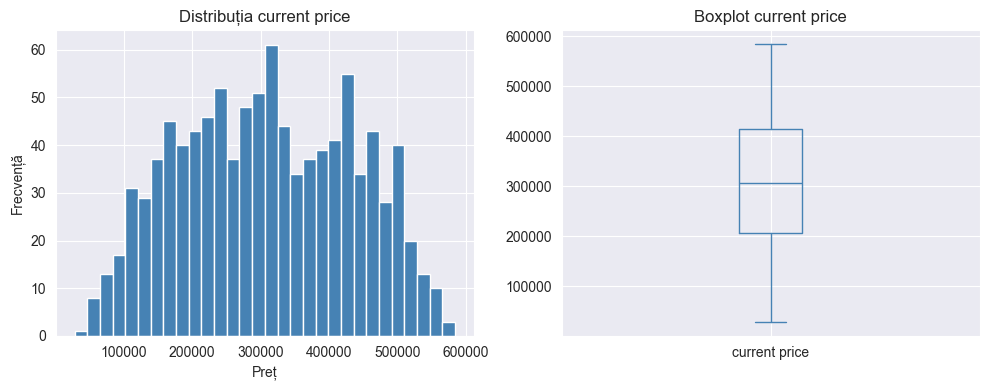

Medie:   308,520
Mediană: 306,718
Std:     126,073
Min:     28,226
Max:     584,268


In [2]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df['current price'].hist(bins=30, color='steelblue', edgecolor='white')
plt.title('Distribuția current price')
plt.xlabel('Preț')
plt.ylabel('Frecvență')

plt.subplot(1, 2, 2)
df['current price'].plot(kind='box', color='steelblue')
plt.title('Boxplot current price')

plt.tight_layout()
plt.show()

print(f'Medie:   {df["current price"].mean():,.0f}')
print(f'Mediană: {df["current price"].median():,.0f}')
print(f'Std:     {df["current price"].std():,.0f}')
print(f'Min:     {df["current price"].min():,.0f}')
print(f'Max:     {df["current price"].max():,.0f}')

## 2.2 Gestionarea anomaliilor

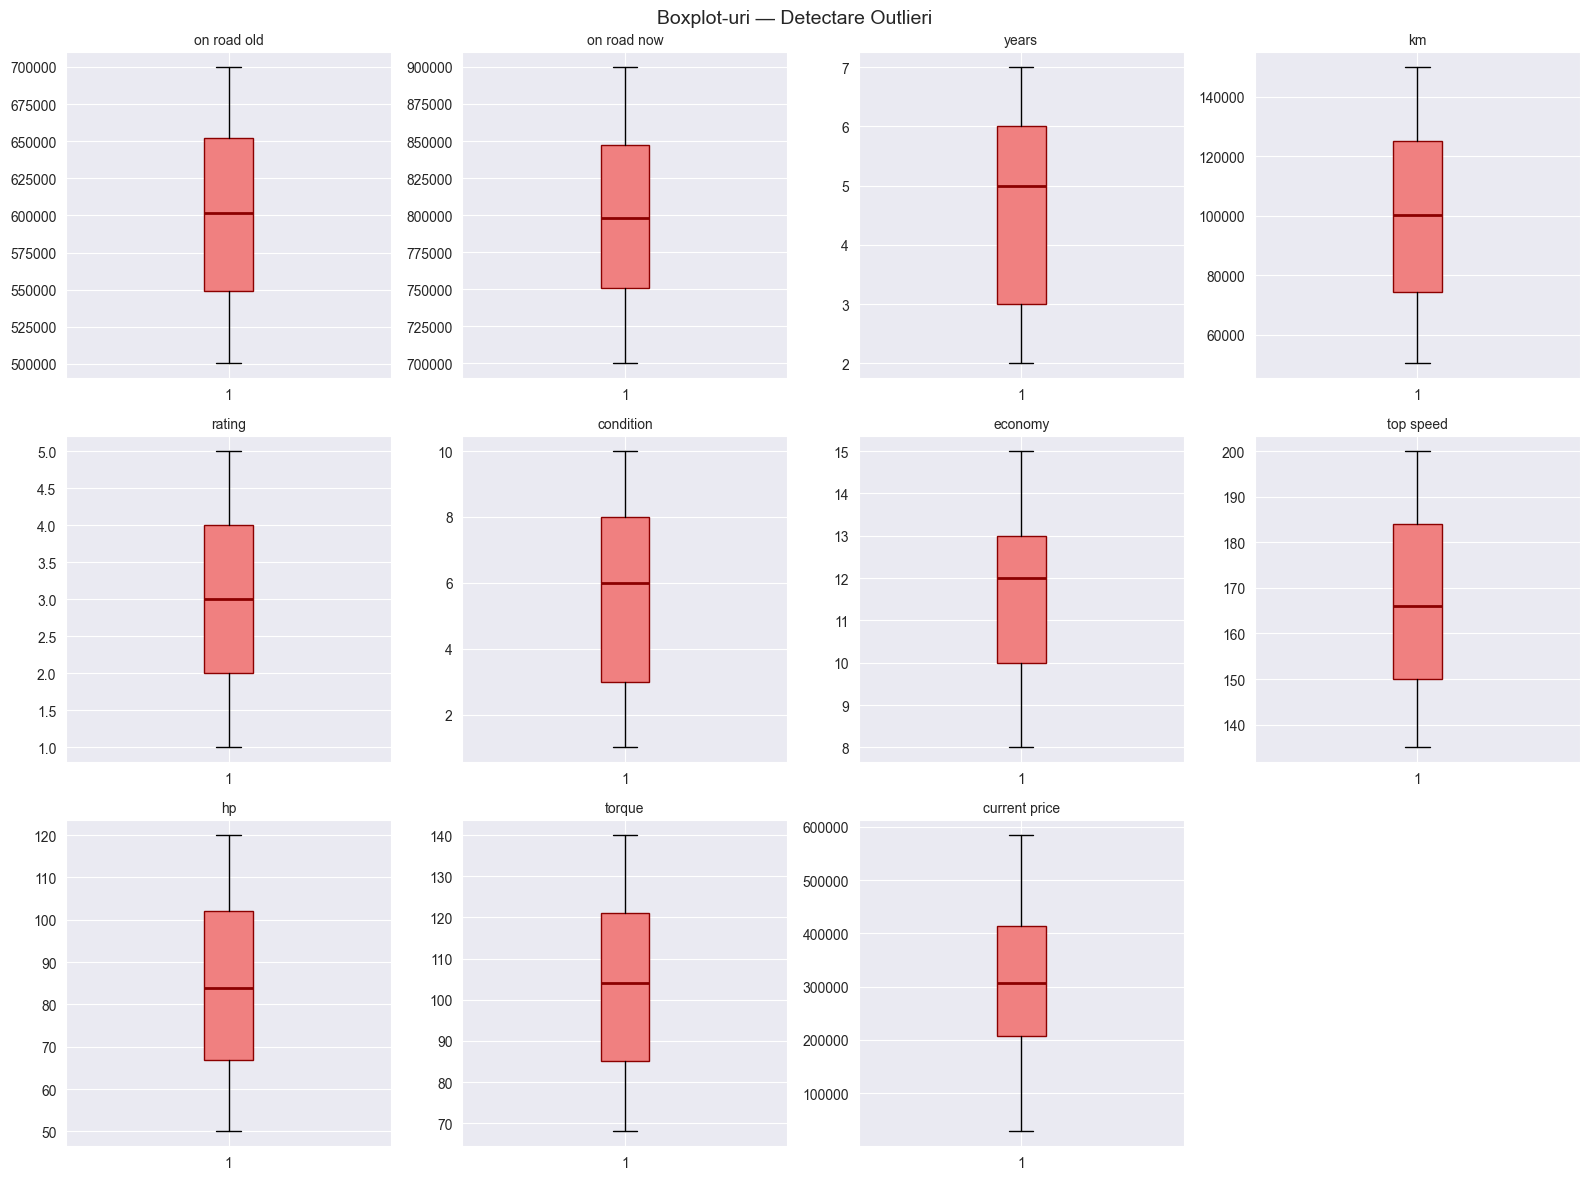

In [3]:
num_cols = ['on road old', 'on road now', 'years', 'km',
            'rating', 'condition', 'economy', 'top speed',
            'hp', 'torque', 'current price']

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', color='darkred'),
                    medianprops=dict(color='darkred', linewidth=2))
    axes[i].set_title(col, fontsize=10)

axes[-1].set_visible(False)
plt.suptitle('Boxplot-uri — Detectare Outlieri', fontsize=14)
plt.tight_layout()
plt.show()

## 2.3 Gestionarea diferitelor tipuri de date - distributia variabilelor numerice

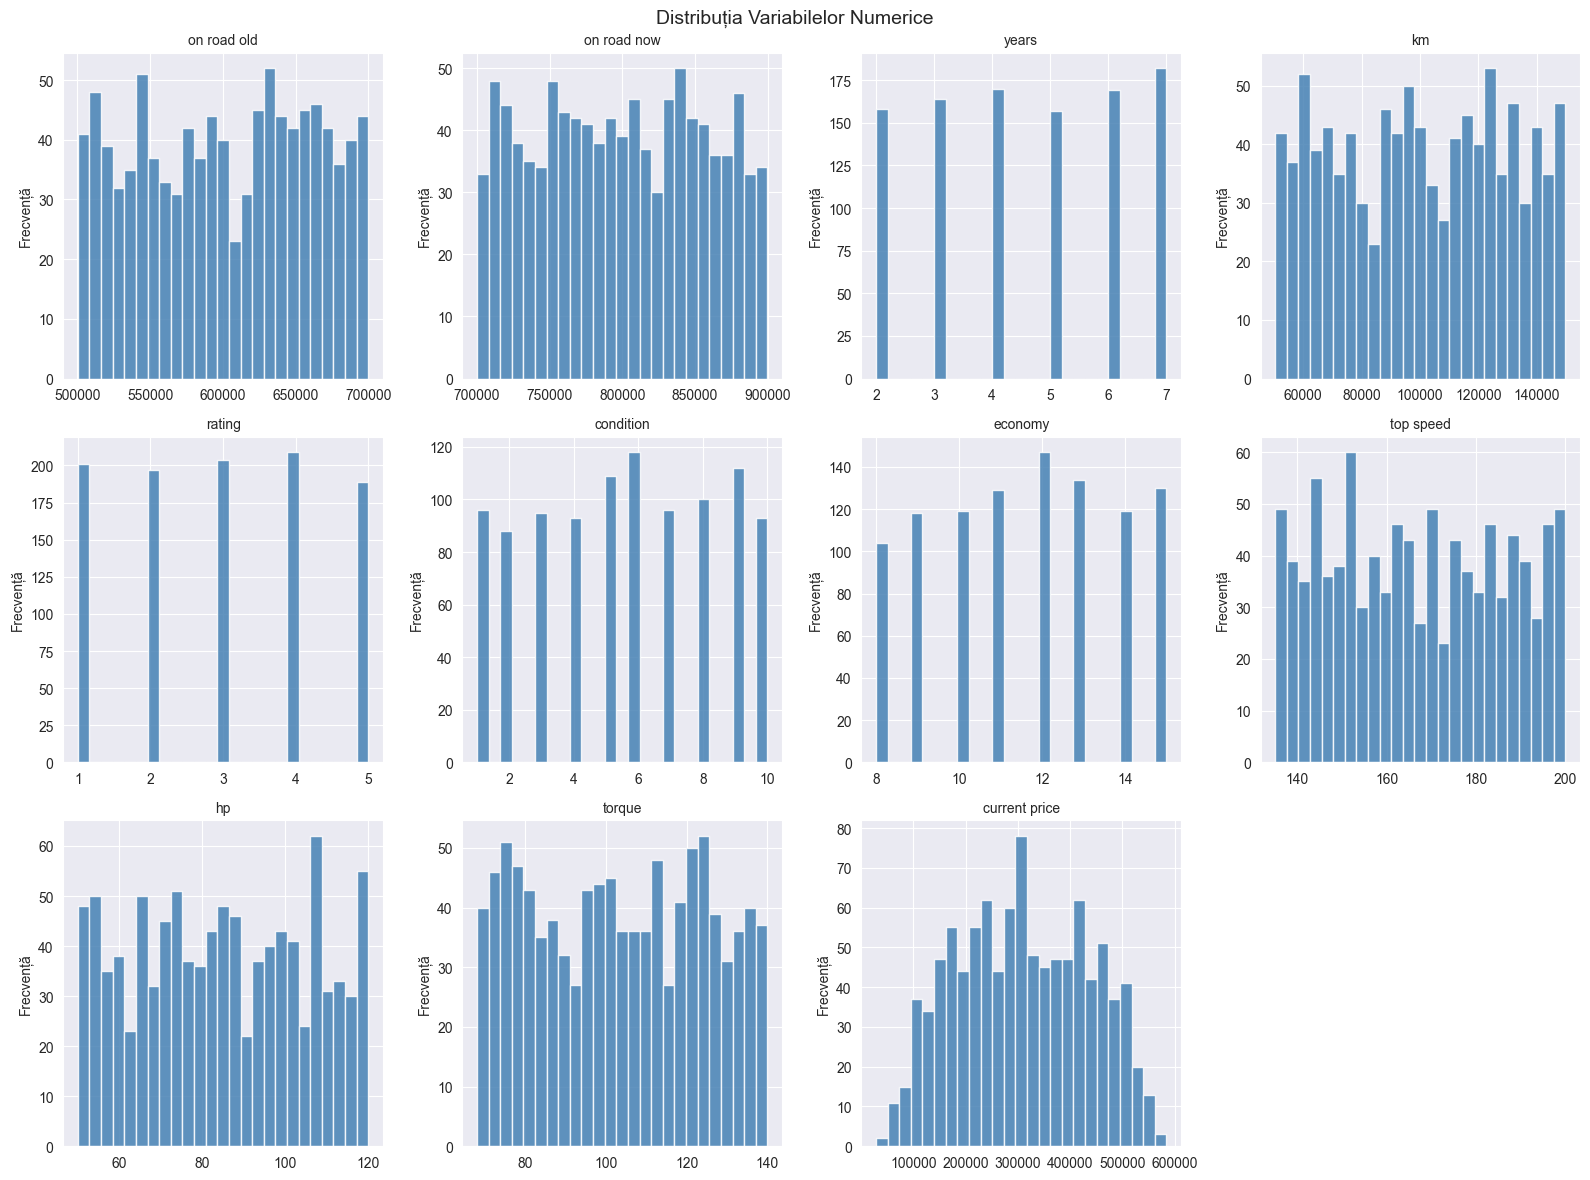

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=25, color='steelblue',
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Frecvență')

axes[-1].set_visible(False)
plt.suptitle('Distribuția Variabilelor Numerice', fontsize=14)
plt.tight_layout()
plt.show()

## 2.4 Analiza corelațiilor între variabile

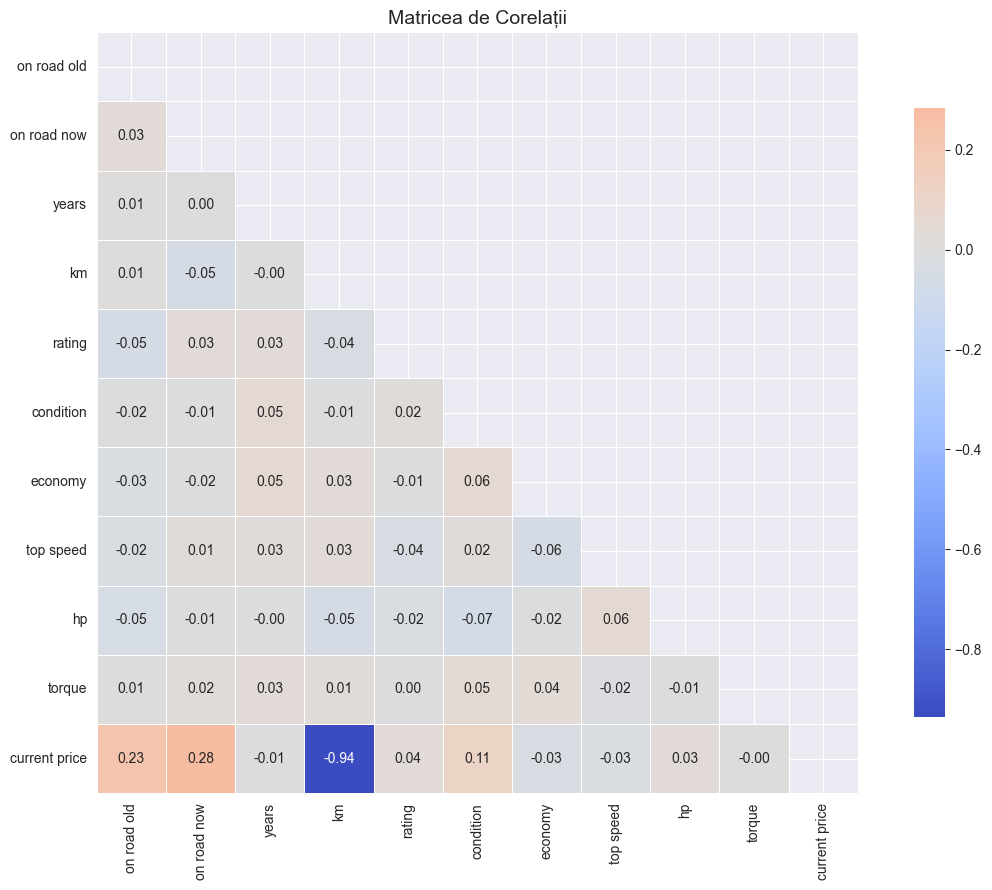

In [5]:
plt.figure(figsize=(12, 9))
corr = df.drop(columns=['v.id']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Matricea de Corelații', fontsize=14)
plt.tight_layout()
plt.show()

## 2.5 Analiza corelatiilor între variabile și țintă( burnout)

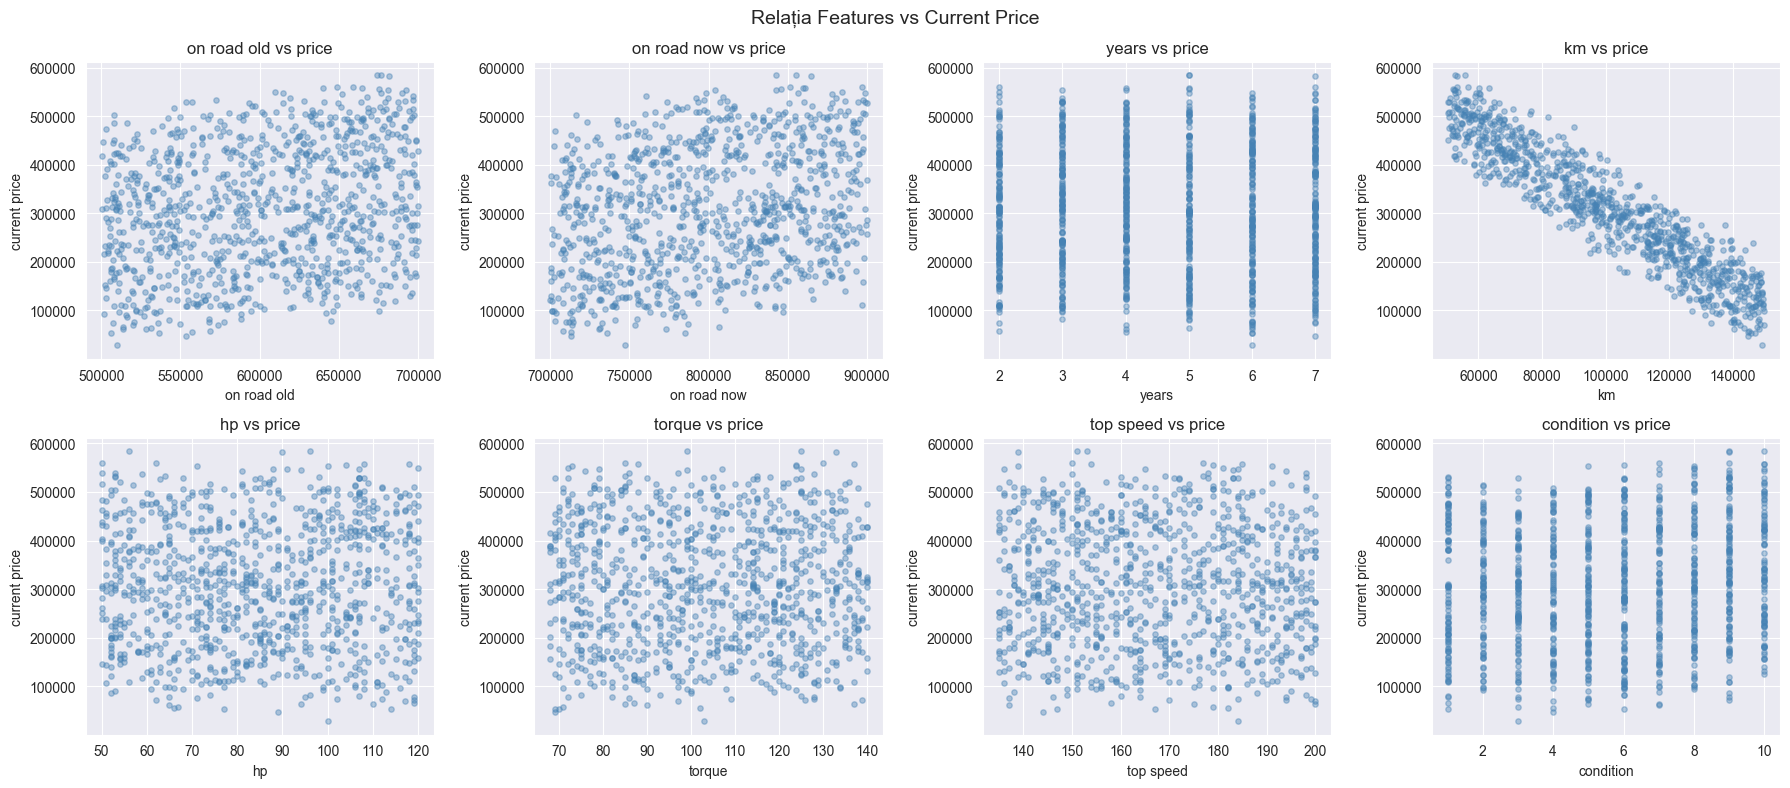

In [6]:
features = ['on road old', 'on road now', 'years', 'km',
            'hp', 'torque', 'top speed', 'condition']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].scatter(df[col], df['current price'],
                    alpha=0.4, color='steelblue', s=15)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('current price')
    axes[i].set_title(f'{col} vs price')

plt.suptitle('Relația Features vs Current Price', fontsize=14)
plt.tight_layout()
plt.show()

## 2.6 Pregătirea datelor pentru modelare

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from interpret.glassbox import ExplainableBoostingRegressor

from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)

# ── Pregătire date ────────────────────────────────────
df_reg = df.drop(columns=['v.id']).copy()

X = df_reg.drop(columns=['current price'])
y = df_reg['current price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 750 | Test: 250


---
# 3. Antrenarea si compararea modelelor de baza


In [8]:
models_reg = {
    'Linear Regression':    LinearRegression(),
    'Decision Tree':        DecisionTreeRegressor(random_state=42),
    'Random Forest':        RandomForestRegressor(random_state=42),
    'SVR':                  SVR(),
    'KNN':                  KNeighborsRegressor(),
    'Gaussian Process':     GaussianProcessRegressor(random_state=42),
    'XGBoost':              XGBRegressor(random_state=42, verbosity=0),
    'CatBoost':             CatBoostRegressor(random_state=42, verbose=0),
    'EBM':                  ExplainableBoostingRegressor(random_state=42)
}

results_reg = []
for name, model in models_reg.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mse  = mean_squared_error(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)

    results_reg.append({
        'Model': name,
        'MSE':   round(mse, 2),
        'MAE':   round(mae, 2),
        'RMSE':  round(rmse, 2),
        'R²':    round(r2, 4)
    })
    print(f'✅ {name} antrenat! R²={r2:.4f}')

df_reg_results = (pd.DataFrame(results_reg)
                    .sort_values('R²', ascending=False)
                    .reset_index(drop=True))
df_reg_results.index += 1
print('\n')
print(df_reg_results.to_string())

✅ Linear Regression antrenat! R²=0.9949
✅ Decision Tree antrenat! R²=0.9410
✅ Random Forest antrenat! R²=0.9799
✅ SVR antrenat! R²=-0.0020
✅ KNN antrenat! R²=0.8370
✅ Gaussian Process antrenat! R²=-0.7370
✅ XGBoost antrenat! R²=0.9846
✅ CatBoost antrenat! R²=0.9980
✅ EBM antrenat! R²=1.0000


               Model           MSE        MAE       RMSE      R²
1                EBM  5.213088e+05     569.48     722.02  1.0000
2           CatBoost  3.190072e+07    3826.35    5648.07  0.9980
3  Linear Regression  7.934205e+07    7544.45    8907.42  0.9949
4            XGBoost  2.421627e+08   12266.22   15561.58  0.9846
5      Random Forest  3.153513e+08   13674.13   17758.13  0.9799
6      Decision Tree  9.247866e+08   24322.45   30410.30  0.9410
7                KNN  2.555485e+09   41146.91   50551.80  0.8370
8                SVR  1.571061e+10  105576.18  125341.98 -0.0020
9   Gaussian Process  2.723576e+10  131548.93  165032.60 -0.7370


## 3.1 Tabel Markdown top 5

In [9]:
print(df_reg_results.head(5).to_markdown())

|    | Model             |              MSE |      MAE |     RMSE |     R² |
|---:|:------------------|-----------------:|---------:|---------:|-------:|
|  1 | EBM               | 521309           |   569.48 |   722.02 | 1      |
|  2 | CatBoost          |      3.19007e+07 |  3826.35 |  5648.07 | 0.998  |
|  3 | Linear Regression |      7.9342e+07  |  7544.45 |  8907.42 | 0.9949 |
|  4 | XGBoost           |      2.42163e+08 | 12266.2  | 15561.6  | 0.9846 |
|  5 | Random Forest     |      3.15351e+08 | 13674.1  | 17758.1  | 0.9799 |


---
# 4. Ajustarea hiperparametrilor

In [10]:
#Importuri
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
import warnings
warnings.filterwarnings('ignore')

cv = KFold(n_splits=5, shuffle=True, random_state=42)

## 4.1 EBM — GridSearchCV

In [ ]:
param_grid_ebm = {
    'max_bins':         [128, 256, 512],
    'max_interaction_bins': [16, 32, 64],
    'interactions':     [0, 5, 10],
    'learning_rate':    [0.001, 0.01, 0.05]
}

grid_ebm = GridSearchCV(
    ExplainableBoostingRegressor(random_state=42),
    param_grid_ebm,
    cv=cv,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_ebm.fit(X_train_scaled, y_train)

print(f'✅ Best params EBM: {grid_ebm.best_params_}')
print(f'   Best CV R²:      {grid_ebm.best_score_:.4f}')

Fitting 5 folds for each of 81 candidates, totalling 405 fits


## 4.2 CatBoost — BayesSearchCV

In [ ]:
param_bayes_cat_reg = {
    'iterations':          Integer(100, 500),
    'depth':               Integer(3, 10),
    'learning_rate':       Real(0.01, 0.3, prior='log-uniform'),
    'l2_leaf_reg':         Real(1, 10),
    'bagging_temperature': Real(0, 1)
}

bayes_cat_reg = BayesSearchCV(
    CatBoostRegressor(random_state=42, verbose=0),
    param_bayes_cat_reg,
    n_iter=30,
    cv=cv,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
bayes_cat_reg.fit(X_train_scaled, y_train)

print(f'✅ Best params CatBoost: {bayes_cat_reg.best_params_}')
print(f'   Best CV R²:           {bayes_cat_reg.best_score_:.4f}')

## 4.3 Linear Regression — GridSearchCV

In [ ]:
param_grid_lr_reg = {
    'fit_intercept': [True, False],
    'positive':      [True, False]
}

grid_lr_reg = GridSearchCV(
    LinearRegression(),
    param_grid_lr_reg,
    cv=cv,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_lr_reg.fit(X_train_scaled, y_train)

print(f'✅ Best params LR: {grid_lr_reg.best_params_}')
print(f'   Best CV R²:     {grid_lr_reg.best_score_:.4f}')

## 4.4 XGBoost — BayesSearchCV

In [ ]:
param_bayes_xgb_reg = {
    'n_estimators':     Integer(100, 500),
    'max_depth':        Integer(3, 10),
    'learning_rate':    Real(0.01, 0.3, prior='log-uniform'),
    'subsample':        Real(0.6, 1.0),
    'colsample_bytree': Real(0.6, 1.0),
    'reg_alpha':        Real(0, 1),
    'reg_lambda':       Real(1, 5)
}

bayes_xgb_reg = BayesSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_bayes_xgb_reg,
    n_iter=30,
    cv=cv,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
bayes_xgb_reg.fit(X_train_scaled, y_train)

print(f'✅ Best params XGB: {bayes_xgb_reg.best_params_}')
print(f'   Best CV R²:      {bayes_xgb_reg.best_score_:.4f}')

## 4.5 Random Forest — BayesSearchCV

In [ ]:
param_bayes_rf_reg = {
    'n_estimators':      Integer(100, 500),
    'max_depth':         Integer(3, 20),
    'min_samples_split': Integer(2, 20),
    'min_samples_leaf':  Integer(1, 10),
    'max_features':      Categorical(['sqrt', 'log2'])
}

bayes_rf_reg = BayesSearchCV(
    RandomForestRegressor(random_state=42),
    param_bayes_rf_reg,
    n_iter=30,
    cv=cv,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
bayes_rf_reg.fit(X_train_scaled, y_train)

print(f'✅ Best params RF: {bayes_rf_reg.best_params_}')
print(f'   Best CV R²:     {bayes_rf_reg.best_score_:.4f}')

## 4.6 Compararea performanțelor după ajustarea hiperparametrilor

In [ ]:
tuned_models_reg = {
    'EBM':               grid_ebm.best_estimator_,
    'CatBoost':          bayes_cat_reg.best_estimator_,
    'Linear Regression': grid_lr_reg.best_estimator_,
    'XGBoost':           bayes_xgb_reg.best_estimator_,
    'Random Forest':     bayes_rf_reg.best_estimator_,
}

tuned_results_reg = []
print('📊 Verificare overfitting (Train vs Test R²):\n')

for name, model in tuned_models_reg.items():
    y_pred    = model.predict(X_test_scaled)
    test_r2   = r2_score(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_mae  = mean_absolute_error(y_test, y_pred)
    test_mse  = mean_squared_error(y_test, y_pred)

    train_r2  = cross_val_score(
                    model, X_train_scaled, y_train,
                    cv=cv, scoring='r2'
                ).mean()

    diff   = train_r2 - test_r2
    status = '⚠️ overfit' if diff > 0.05 else '✅ ok'

    print(f'  {name:<20} Train R²: {train_r2:.4f}  '
          f'Test R²: {test_r2:.4f}  Δ={diff:.4f}  {status}')

    tuned_results_reg.append({
        'Model': name,
        'MSE':   round(test_mse, 2),
        'MAE':   round(test_mae, 2),
        'RMSE':  round(test_rmse, 2),
        'R²':    round(test_r2, 4)
    })

df_tuned_reg = (pd.DataFrame(tuned_results_reg)
                  .sort_values('R²', ascending=False)
                  .reset_index(drop=True))
df_tuned_reg.index += 1

print('\n')
print(df_tuned_reg.to_string())

## 4.7 Tabel Markdown + Grafic comparativ

In [ ]:
print(df_tuned_reg.to_markdown())
# Grafic R² comparativ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² — mai mare e mai bun
colors = ['gold' if i == 0 else 'steelblue'
          for i in range(len(df_tuned_reg))]

axes[0].barh(df_tuned_reg['Model'], df_tuned_reg['R²'],
             color=colors, edgecolor='white')
axes[0].set_xlabel('R² Score')
axes[0].set_title('R² — mai mare e mai bun')
axes[0].axvline(0.99, color='red', linestyle='--',
                linewidth=1, label='Prag 0.99')
axes[0].legend()

# RMSE — mai mic e mai bun
colors_rmse = ['gold' if i == len(df_tuned_reg)-1 else 'steelblue'
               for i in range(len(df_tuned_reg))]
df_sorted_rmse = df_tuned_reg.sort_values('RMSE', ascending=True)

axes[1].barh(df_sorted_rmse['Model'], df_sorted_rmse['RMSE'],
             color=['gold'] + ['steelblue'] * 4, edgecolor='white')
axes[1].set_xlabel('RMSE')
axes[1].set_title('RMSE — mai mic e mai bun')

plt.suptitle('Comparație Modele Tuned — Regresie', fontsize=14)
plt.tight_layout()
plt.show()

---
# 5. Curbe de învățare

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

train_sizes_pct = np.linspace(0.1, 1.0, 8)

for i, (name, model) in enumerate(tuned_models_reg.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_train_scaled, y_train,
        train_sizes=train_sizes_pct,
        cv=cv,
        scoring='r2',
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax = axes[i]

    ax.plot(train_sizes, train_mean, 'o-', color='steelblue',
            label='Train', linewidth=2)
    ax.plot(train_sizes, val_mean, 'o--', color='coral',
            label='Validare', linewidth=2)

    ax.fill_between(train_sizes,
                    train_mean - train_std,
                    train_mean + train_std,
                    alpha=0.15, color='steelblue')
    ax.fill_between(train_sizes,
                    val_mean - val_std,
                    val_mean + val_std,
                    alpha=0.15, color='coral')

    gap    = train_mean[-1] - val_mean[-1]
    if gap > 0.05:
        status = '⚠️ Overfit'
        color  = 'red'
    elif val_mean[-1] < 0.7:
        status = '⚠️ Underfit'
        color  = 'orange'
    else:
        status = '✅ OK'
        color  = 'green'

    ax.set_title(f'{name}\n'
                 f'Train={train_mean[-1]:.3f} | '
                 f'Val={val_mean[-1]:.3f} | '
                 f'Δ={gap:.3f} → {status}',
                 fontsize=10, color=color)
    ax.set_xlabel('Număr exemple antrenare')
    ax.set_ylabel('R² Score')
    ax.legend(loc='lower right')
    ax.set_ylim(-0.1, 1.05)
    ax.grid(True, alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('Curbe de Învățare — Top 5 Modele Regresie', fontsize=15)
plt.tight_layout()
plt.show()

---
# 6. Explicabilitatea și analiza SHAP

In [ ]:
import shap
shap.initjs()

# Primele 3 modele tuned
top3_reg = {
    'EBM':      grid_ebm.best_estimator_,
    'CatBoost': bayes_cat_reg.best_estimator_,
    'XGBoost':  bayes_xgb_reg.best_estimator_,
}

# Subset pentru viteză — 300 exemple suficiente
X_test_df  = pd.DataFrame(X_test_scaled, columns=X.columns)
X_explain  = X_test_df.sample(300, random_state=42).reset_index(drop=True)

## 6.1 EBM — SHAP

In [ ]:
print('=' * 50)
print('SHAP — EBM (Explainable Boosting Regressor)')
print('=' * 50)

explainer_ebm   = shap.Explainer(grid_ebm.best_estimator_)
shap_values_ebm = explainer_ebm(X_explain)

# Global 1: Summary Plot (beeswarm)
plt.figure()
shap.summary_plot(
    shap_values_ebm,
    X_explain,
    show=True
)

# Global 2: Bar Plot
plt.figure()
shap.summary_plot(
    shap_values_ebm,
    X_explain,
    plot_type='bar',
    show=True
)

# Local: Waterfall Plot — primul exemplu
plt.figure()
shap.plots.waterfall(shap_values_ebm[0])

# Local: Force Plot
shap.plots.force(shap_values_ebm[0], matplotlib=True)
plt.title('Force Plot — EBM — primul exemplu')
plt.tight_layout()
plt.show()

# Top 3 features pentru Scatter
importances_ebm  = np.abs(shap_values_ebm.values).mean(axis=0)
top3_feat_ebm    = X_explain.columns[
                       np.argsort(importances_ebm)[-3:]
                   ].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(top3_feat_ebm):
    shap.dependence_plot(
        feat,
        shap_values_ebm.values,
        X_explain,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'Scatter SHAP — {feat}')
plt.suptitle('SHAP Scatter Plots — EBM', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Top 3 features EBM: {top3_feat_ebm}')

## 6.2 CatBoost — SHAP

In [ ]:
print('=' * 50)
print('SHAP — CatBoost Regressor')
print('=' * 50)

explainer_cat_reg   = shap.TreeExplainer(bayes_cat_reg.best_estimator_)
shap_values_cat_reg = explainer_cat_reg.shap_values(X_explain)

# Global 1: Summary Plot
plt.figure()
shap.summary_plot(
    shap_values_cat_reg,
    X_explain,
    show=True
)

# Global 2: Bar Plot
plt.figure()
shap.summary_plot(
    shap_values_cat_reg,
    X_explain,
    plot_type='bar',
    show=True
)

# Local: Waterfall Plot
plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_cat_reg[0],
        base_values=explainer_cat_reg.expected_value,
        data=X_explain.iloc[0],
        feature_names=X_explain.columns.tolist()
    )
)

# Local: Force Plot
shap.force_plot(
    explainer_cat_reg.expected_value,
    shap_values_cat_reg[0],
    X_explain.iloc[0],
    feature_names=X_explain.columns.tolist(),
    matplotlib=True
)
plt.title('Force Plot — CatBoost — primul exemplu')
plt.tight_layout()
plt.show()

# Scatter Plots
importances_cat_reg  = np.abs(shap_values_cat_reg).mean(axis=0)
top3_feat_cat_reg    = X_explain.columns[
                           np.argsort(importances_cat_reg)[-3:]
                       ].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(top3_feat_cat_reg):
    shap.dependence_plot(
        feat,
        shap_values_cat_reg,
        X_explain,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'Scatter SHAP — {feat}')
plt.suptitle('SHAP Scatter Plots — CatBoost', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Top 3 features CatBoost: {top3_feat_cat_reg}')

## 6.3 XGBoost — SHAP

In [ ]:
print('=' * 50)
print('SHAP — XGBoost Regressor')
print('=' * 50)

explainer_xgb_reg   = shap.TreeExplainer(bayes_xgb_reg.best_estimator_)
shap_values_xgb_reg = explainer_xgb_reg.shap_values(X_explain)

# Global 1: Summary Plot
plt.figure()
shap.summary_plot(
    shap_values_xgb_reg,
    X_explain,
    show=True
)

# Global 2: Bar Plot
plt.figure()
shap.summary_plot(
    shap_values_xgb_reg,
    X_explain,
    plot_type='bar',
    show=True
)

# Local: Waterfall Plot
plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_xgb_reg[0],
        base_values=explainer_xgb_reg.expected_value,
        data=X_explain.iloc[0],
        feature_names=X_explain.columns.tolist()
    )
)

# Local: Force Plot
shap.force_plot(
    explainer_xgb_reg.expected_value,
    shap_values_xgb_reg[0],
    X_explain.iloc[0],
    feature_names=X_explain.columns.tolist(),
    matplotlib=True
)
plt.title('Force Plot — XGBoost — primul exemplu')
plt.tight_layout()
plt.show()

# Scatter Plots
importances_xgb_reg  = np.abs(shap_values_xgb_reg).mean(axis=0)
top3_feat_xgb_reg    = X_explain.columns[
                           np.argsort(importances_xgb_reg)[-3:]
                       ].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(top3_feat_xgb_reg):
    shap.dependence_plot(
        feat,
        shap_values_xgb_reg,
        X_explain,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'Scatter SHAP — {feat}')
plt.suptitle('SHAP Scatter Plots — XGBoost', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Top 3 features XGBoost: {top3_feat_xgb_reg}')

Diferența față de clasificare:

        La regresie valorile SHAP arată direct cu câți bani contribuie fiecare feature la prețul prezis.
    Waterfall Plot — exemplu de interpretare:
    E[f(x)] = 308.520 INR  ← prețul mediu din dataset

    on road now   = +85.340 INR  ← mașina are preț pe șosea ridicat → scumpă
    km            = -23.100 INR  ← kilometraj mare → ieftinește mașina
    condition     = +12.800 INR  ← stare bună → crește prețul
    years         = -8.500 INR   ← mai veche → scade prețul
    ...
    f(x) = 374.060 INR  ← prețul final prezis

Pentru scatter plots comentezi:

    on road now vs SHAP:
    → linie crescătoare → prețul pe șosea mai mare = SHAP pozitiv
    → mașinile cu on road now ridicat sunt prezise mai scumpe ✅ logic

    km vs SHAP:
    → linie descrescătoare → km mai mulți = SHAP negativ
    → kilometraj mare scade prețul ✅ logic

    condition vs SHAP:
    → linie crescătoare → stare mai bună = SHAP pozitiv ✅ logic

In [ ]:
import joblib

reg_models_to_save = {
    'EBM':               grid_ebm.best_estimator_,
    'CatBoost':          bayes_cat_reg.best_estimator_,
    'Linear Regression': grid_lr_reg.best_estimator_,
    'XGBoost':           bayes_xgb_reg.best_estimator_,
    'Random Forest':     bayes_rf_reg.best_estimator_,
}
joblib.dump(reg_models_to_save, 'models/reg_models.pkl')
joblib.dump(scaler,             'models/reg_scaler.pkl')
joblib.dump(X.columns.tolist(), 'models/reg_feature_names.pkl')
print('✅ Modele regresie salvate!')